In [4]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, date, timedelta
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors

FORD, GOODYEAR, HARLEY DAVIDSON. STEP DOWN CASH COLLECT

In [5]:
# PREZZO CERTIFICATE
prezzo = 909.3

In [6]:
# DATI PANIERE

yf.set_tz_cache_location("C:/yf_cache")

tickers = ["F","GT","HOG"]
dati = yf.download(tickers, period="max", auto_adjust=False)["Close"]
dati.dropna(inplace=True)
dati = dati.reindex(pd.date_range(str(dati.index[0]), str(dati.index[-1])), method="ffill")


[*********************100%***********************]  3 of 3 completed


In [7]:
dati.head(30)

Ticker,F,GT,HOG
1986-07-08,4.721573,15.9375,0.343750
1986-07-09,4.744383,16.0000,0.398438
1986-07-10,4.778597,16.2500,0.406250
1986-07-11,4.767192,16.1250,0.433594
1986-07-12,4.767192,16.1250,0.433594
1986-07-13,4.767192,16.1250,0.433594
1986-07-14,4.835621,15.8125,0.390625
1986-07-15,4.835621,15.3750,0.386719
1986-07-16,4.892645,15.7500,0.371094
1986-07-17,5.040907,15.5000,0.363281


<Axes: >

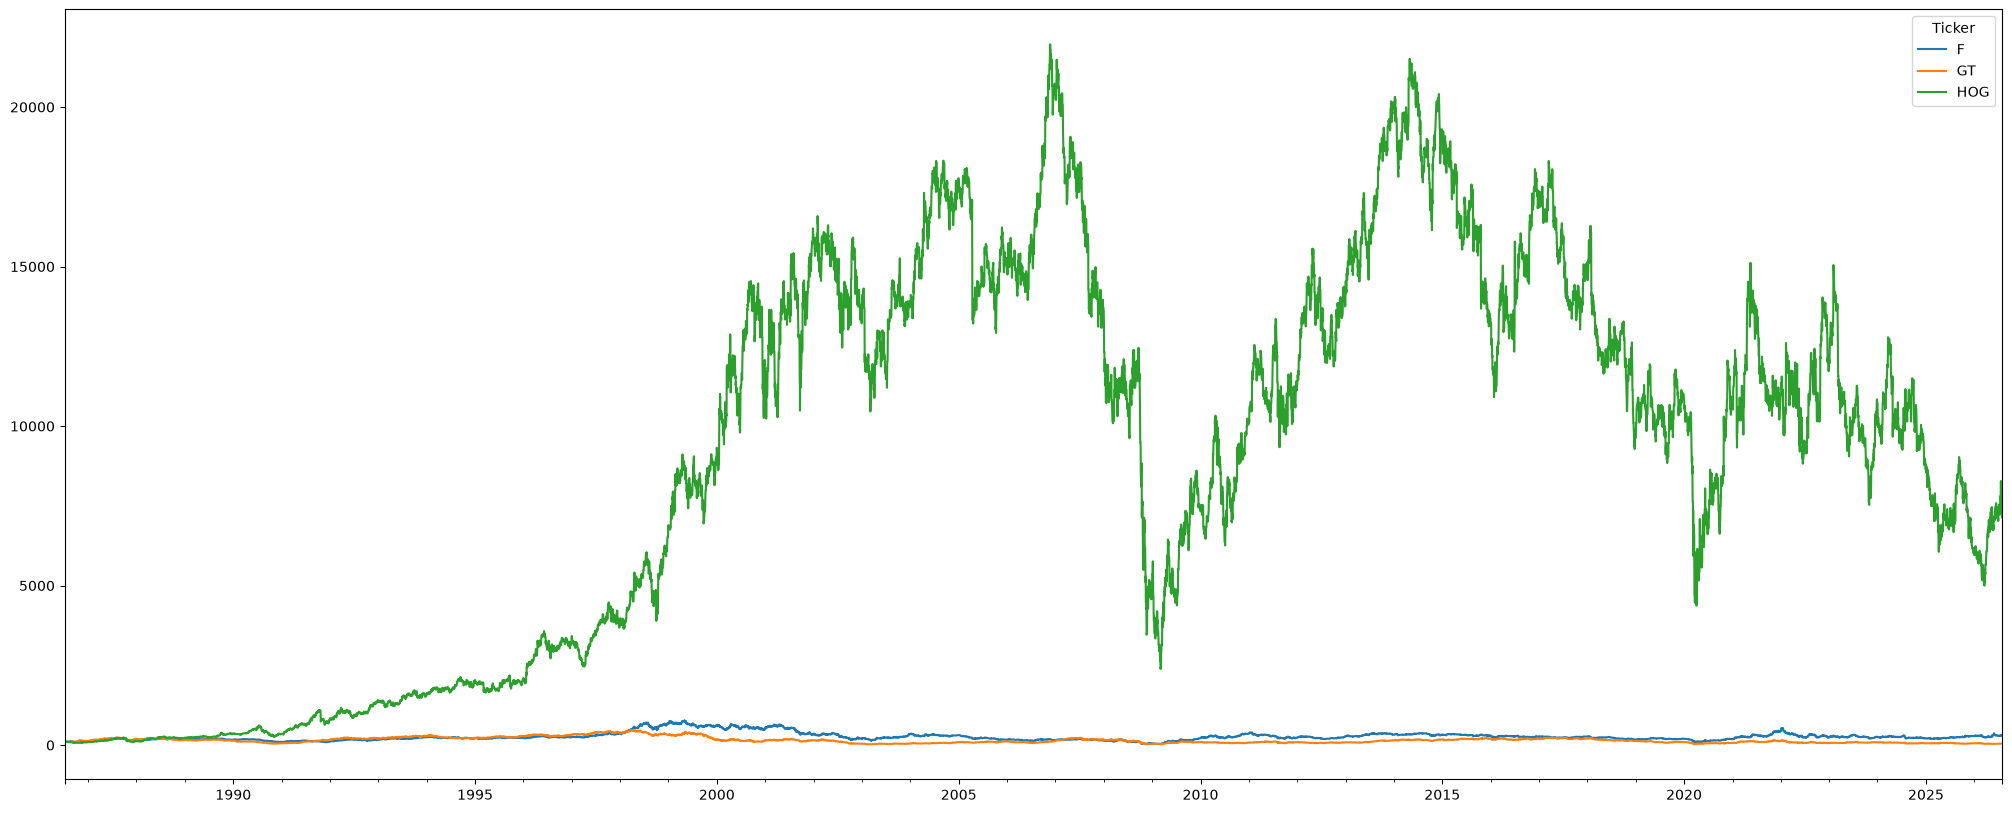

In [8]:
(100*dati/dati.iloc[0]).plot(figsize=(25,10))

In [9]:
rimborso = 1000
fixing = dict(zip(tickers, [11.07,9.33,32.65]))
barriere = dict(zip(tickers, [5.535,4.665,16.325]))
date_rimborso_anticipato = [
                datetime.strptime("14.08.2026", '%d.%m.%Y').date(),
                datetime.strptime("14.09.2026", '%d.%m.%Y').date(),
                datetime.strptime("14.10.2026", '%d.%m.%Y').date()
                ]
autocall_perc = [0.85,0.84,0.83]
fine = datetime.strptime("16.11.2026", '%d.%m.%Y').date()

In [10]:
#PREMIO MENSILE
premio_importo = rimborso * 0.0095

def premi_incassati(data_rimborso):
    n = sum(1 for d in date_rimborso_anticipato if d <= data_rimborso)
    return n * premio_importo

In [11]:
giorni_durata = abs((datetime.today().date()-fine).days)   

# cattura il prezzo VERO di oggi, prima del dropna della cella 8
spot = {t: dati[t].iloc[-1] for t in tickers}

dati["finale_media"] = 0
for t in tickers:
    for i in range(len(date_rimborso_anticipato)):
        gg = (date_rimborso_anticipato[i]-datetime.today().date()).days   
        if gg > 0:
            dati["autocall_"+t+"_"+str(i)] = dati[t].shift(-gg)/dati[t] - 1
    dati["finale_"+t] = dati[t].shift(-giorni_durata)/dati[t] - 1
    dati["finale_media"] += dati["finale_"+t]/len(tickers)

dati.dropna(inplace=True)

In [12]:
dati

Ticker,F,GT,HOG,finale_media,autocall_F_0,autocall_F_1,autocall_F_2,finale_F,autocall_GT_0,autocall_GT_1,autocall_GT_2,finale_GT,autocall_HOG_0,autocall_HOG_1,autocall_HOG_2,finale_HOG
1986-07-08,4.721573,15.9375,0.343750,0.049940,0.096618,0.198068,0.004831,0.142512,-0.031373,0.086275,0.007843,0.325490,0.022729,-0.090909,-0.215910,-0.318182
1986-07-09,4.744383,16.0000,0.398438,0.024241,0.093750,0.192308,0.000000,0.115385,-0.050781,0.062500,0.003906,0.378906,-0.078431,-0.245100,-0.323531,-0.421569
1986-07-10,4.778597,16.2500,0.406250,0.010800,0.073986,0.183771,0.031026,0.107399,-0.023077,0.046154,0.007692,0.357692,-0.076923,-0.259616,-0.365383,-0.432692
1986-07-11,4.767192,16.1250,0.433594,0.003266,0.071770,0.186603,0.043062,0.110048,-0.023256,0.054264,0.011628,0.368217,-0.180180,-0.306307,-0.405405,-0.468468
1986-07-12,4.767192,16.1250,0.433594,0.048904,0.090909,0.177034,0.023924,0.110048,-0.023256,0.038760,0.015504,0.496124,-0.144144,-0.306307,-0.414415,-0.459460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-11,12.130000,7.1000,22.790001,0.099796,0.020610,0.230833,0.140973,0.210223,-0.005634,-0.170423,-0.114085,0.001408,0.014041,0.041246,0.121106,0.087758
2026-04-12,12.130000,7.1000,22.790001,0.126541,0.020610,0.262984,0.163232,0.233306,-0.005634,-0.150704,-0.092958,0.036620,0.014041,0.018429,0.117157,0.109697
2026-04-13,12.160000,7.0300,22.889999,0.125631,0.018092,0.305921,0.162007,0.256579,0.004267,-0.133713,-0.027027,0.035562,0.009611,0.055046,0.100481,0.084753
2026-04-14,12.710000,6.8400,23.170000,0.089230,-0.017309,0.309992,0.111723,0.169158,0.043860,-0.093567,0.000000,0.035088,-0.008632,0.040570,0.087182,0.063444


In [13]:
conto_non_normalizzato = False

rendimenti = []
for giorno in range(len(dati)):
    for i in range(len(date_rimborso_anticipato)):
        if (datetime.today().date()-date_rimborso_anticipato[i]).days<0: # escludiamo gli autocall già successi
            autocall = True
            for t in tickers:
                if  spot[t] * (1+dati["autocall_"+t+"_"+str(i)].iloc[giorno]) < fixing[t] * (autocall_perc[i]) :
                    autocall = False
                    break # non c'è autocall e esco dal loop dei tickers

            if autocall:
                if conto_non_normalizzato:
                    incasso = rimborso + premi_incassati(date_rimborso_anticipato[i])
                    rendimenti.append( incasso )
                else:
                    incasso = rimborso + premi_incassati(date_rimborso_anticipato[i])
                    rendimenti.append( (incasso/prezzo)**(365.24/(date_rimborso_anticipato[i]-datetime.today().date()).days) - 1 )
                break # esco anche dal loop degli autocall

    if not autocall: # se arrivo qui con autocall False vuol dire che sono passato attraverso tutti i tentativi di autocall
        chi_rapporto_peggiore = ""
        evento_barriera = False
        rapporto_peggiore_su_fixing = 999
        for t in tickers: # cerco il rapporto peggiore RISPETTO AL PREZZO DI FIXING!
            if spot[t] * (1+dati["finale_"+t].iloc[giorno]) <= barriere[t]: # scatta evento barriera
                rapporto = (spot[t] * (1+dati["finale_"+t].iloc[giorno]) ) /fixing[t] # questo rapporto è per forza <= 0.5
                if evento_barriera:
                    if rapporto < rapporto_peggiore_su_fixing:
                        chi_rapporto_peggiore = t
                        rapporto_peggiore_su_fixing = rapporto
                else:
                    evento_barriera = True
                    chi_rapporto_peggiore = t
                    rapporto_peggiore_su_fixing = rapporto

        if evento_barriera:
            rimborso_alternativo = max(0,rimborso*rapporto_peggiore_su_fixing)
            if conto_non_normalizzato:
                incasso = rimborso_alternativo + premi_incassati(fine)
                rendimenti.append( incasso )
            else:
                incasso = rimborso_alternativo + premi_incassati(fine)
                rendimenti.append( (incasso/prezzo)**(365.24/(fine-datetime.today().date()).days) - 1 )

        else:
            if conto_non_normalizzato:
                incasso = rimborso + premi_incassati(fine)
                rendimenti.append( incasso )
            else:
                incasso = rimborso + premi_incassati(fine)
                rendimenti.append( (incasso/prezzo)**(365.24/(fine-datetime.today().date()).days) - 1 )


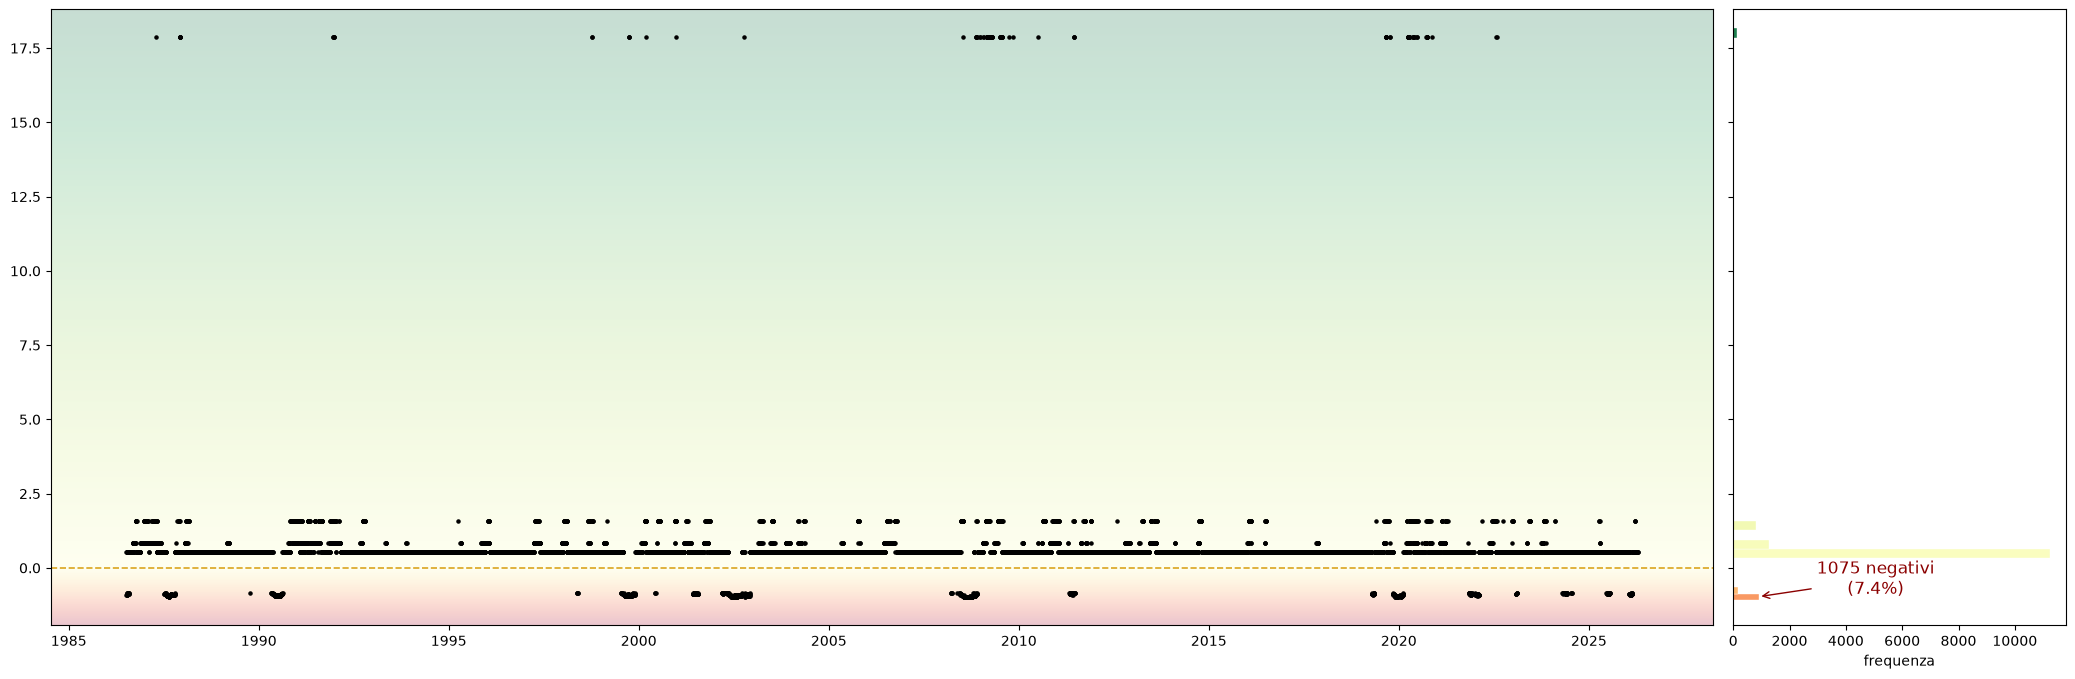

In [14]:
s = pd.Series(rendimenti, index=dati.index)
center = prezzo if conto_non_normalizzato else 0.0

ymin, ymax = s.min(), s.max()
pad = (ymax - ymin) * 0.05
ymin -= pad; ymax += pad
norm = mcolors.TwoSlopeNorm(vmin=ymin, vcenter=center, vmax=ymax)
cmap = plt.get_cmap("RdYlGn")

fig, (ax, axh) = plt.subplots(1, 2, figsize=(26, 8), sharey=True,
                              gridspec_kw={"width_ratios": [5, 1], "wspace": 0.02})

# --- scatter + sfondo semaforo ---
ax.scatter(s.index, s.values, s=5, c="black", zorder=2)
x0, x1 = ax.get_xlim()
ax.imshow(np.linspace(ymax, ymin, 256).reshape(-1, 1), extent=[x0, x1, ymin, ymax],
          aspect="auto", cmap=cmap, norm=norm, alpha=0.22, zorder=0)
ax.axhline(center, color="goldenrod", lw=1.2, ls="--", zorder=1)
ax.set_xlim(x0, x1); ax.set_ylim(ymin, ymax)

# --- istogramma: bin larghi sotto il centro, fitti sopra ---
edges = np.concatenate([np.linspace(ymin, center, 10),      # ~9 bin larghi (perdite)
                        np.linspace(center, ymax, 60)[1:]]) # bin fitti (parte positiva)
counts, edges = np.histogram(s.values, bins=edges)
centers = (edges[:-1] + edges[1:]) / 2
widths = np.diff(edges)
axh.barh(centers, counts, height=widths, color=cmap(norm(centers)),
         alpha=0.9, edgecolor="white", linewidth=0.3)
axh.set_xlabel("frequenza")
axh.tick_params(labelleft=False)

# --- freccina col conteggio dei negativi ---
neg = centers < center
n_neg = int(counts[neg].sum())
pct = n_neg / len(s) * 100
y_neg = centers[neg][np.argmax(counts[neg])]
x_neg = counts[neg].max()
axh.annotate(f"{n_neg} negativi\n({pct:.1f}%)",
             xy=(x_neg, y_neg),                                   
             xytext=(counts.max() * 0.45, center - (center - ymin) * 0.45),  
             ha="center", fontsize=12, color="darkred",
             arrowprops=dict(arrowstyle="->", color="darkred"))

plt.show()

In [15]:
pd.Series(rendimenti,index=dati.index).describe()

count    14527.000000
mean         0.650035
std          1.658722
min         -0.996308
25%          0.522685
50%          0.522685
75%          0.522685
max         17.858454
dtype: float64

## Valutazione tramite Certainty Equivalent (utilità CRRA)

**Equivalente certo** — importo certo che rende indifferente al possesso dello strumento rischioso:

$$\text{CE} = u^{-1}\big(\mathbb{E}[u(X)]\big), \qquad u(x) = \frac{x^{1-\gamma}}{1-\gamma}$$

Sulla distribuzione empirica dei payoff $\{x_i\}_{i=1}^{N}$:

$$\text{CE}(\gamma) = \left(\frac{1}{N}\sum_{i=1}^{N} x_i^{\,1-\gamma}\right)^{\frac{1}{1-\gamma}} \quad (\gamma \neq 1), \qquad \text{CE}(1) = \exp\!\left(\frac{1}{N}\sum_{i=1}^{N} \ln x_i\right)$$

**Valore oggi** (scontato al tasso risk-free $r$ su orizzonte $T$):

$$V(\gamma) = e^{-rT}\,\text{CE}(\gamma)$$

**Casi particolari e interpretazione:**

- $\gamma = 0$ (neutrale al rischio): $\text{CE} = \frac{1}{N}\sum_i x_i = \mathbb{E}[X]$, cioè la sola media → $V = e^{-rT}\,\mathbb{E}[X]$.
- $\gamma > 0$: la concavità di $u$ penalizza la coda sinistra; più alto è $\gamma$, più $\text{CE}$ scende sotto la media.
- **Premio per il rischio:** $\ \pi(\gamma) = \mathbb{E}[X] - \text{CE}(\gamma)$
- **Regola di decisione:** $\ V(\gamma) > \text{prezzo} \Rightarrow$ conviene; $\ V(\gamma) < \text{prezzo} \Rightarrow$ paghi troppo per quel rischio.

## Come interpretare γ: il test della scommessa 50/50

Per dare un significato concreto a γ, traducilo in una scommessa: **50/50 — o raddoppi il capitale, o ne perdi una frazione L**. La massima perdita L che accetteresti individua la tua avversione al rischio.

Condizione di indifferenza (utilità CRRA):

$$0.5 \cdot 2^{\,1-\gamma} + 0.5 \cdot (1-L)^{\,1-\gamma} = 1$$

| γ | Max perdita L accettata per un 50/50 di raddoppiare | Profilo |
|---|---|---|
| 0,5 | 66% | molto aggressivo |
| 1 | 50% | aggressivo (log / Kelly) |
| 2 | 33% | moderato |
| 3 | 24% | moderato-prudente |
| 5 | 15% | prudente |
| 10 | 7% | molto prudente |
| 20 | 4% | avversissimo |

**Lettura:** se pur di avere il 50% di probabilità di raddoppiare accetti di rischiare di perdere metà del capitale → γ ≈ 1; se il massimo che tolleri è −15% → γ ≈ 5.

**Riferimenti empirici:** investitore individuale tipico γ ≈ 2–4; profili prudenti γ ≈ 5–10; fascia realistica complessiva 1–10 (default ragionevole 2–4).

In [16]:
conto_non_normalizzato = True

rendimenti = []
for giorno in range(len(dati)):
    for i in range(len(date_rimborso_anticipato)):
        if (datetime.today().date()-date_rimborso_anticipato[i]).days<0: # escludiamo gli autocall già successi
            autocall = True
            for t in tickers:
                if  spot[t] * (1+dati["autocall_"+t+"_"+str(i)].iloc[giorno]) < fixing[t] * (autocall_perc[i]) :
                    autocall = False
                    break # non c'è autocall e esco dal loop dei tickers

            if autocall:
                if conto_non_normalizzato:
                    incasso = rimborso + premi_incassati(date_rimborso_anticipato[i])
                    rendimenti.append( incasso )
                else:
                    incasso = rimborso + premi_incassati(date_rimborso_anticipato[i])
                    rendimenti.append( (incasso/prezzo)**(365.24/(date_rimborso_anticipato[i]-datetime.today().date()).days) - 1 )
                break # esco anche dal loop degli autocall

    if not autocall: # se arrivo qui con autocall False vuol dire che sono passato attraverso tutti i tentativi di autocall
        chi_rapporto_peggiore = ""
        evento_barriera = False
        rapporto_peggiore_su_fixing = 999
        for t in tickers: # cerco il rapporto peggiore RISPETTO AL PREZZO DI FIXING!
            if spot[t] * (1+dati["finale_"+t].iloc[giorno]) <= barriere[t]: # scatta evento barriera
                rapporto = (spot[t] * (1+dati["finale_"+t].iloc[giorno]) ) /fixing[t] # questo rapporto è per forza <= 0.5
                if evento_barriera:
                    if rapporto < rapporto_peggiore_su_fixing:
                        chi_rapporto_peggiore = t
                        rapporto_peggiore_su_fixing = rapporto
                else:
                    evento_barriera = True
                    chi_rapporto_peggiore = t
                    rapporto_peggiore_su_fixing = rapporto

        if evento_barriera:
            rimborso_alternativo = max(0,rimborso*rapporto_peggiore_su_fixing)
            if conto_non_normalizzato:
                incasso = rimborso_alternativo + premi_incassati(fine)
                rendimenti.append( incasso )
            else:
                incasso = rimborso_alternativo + premi_incassati(fine)
                rendimenti.append( (incasso/prezzo)**(365.24/(fine-datetime.today().date()).days) - 1 )

        else:
            if conto_non_normalizzato:
                incasso = rimborso + premi_incassati(fine)
                rendimenti.append( incasso )
            else:
                incasso = rimborso + premi_incassati(fine)
                rendimenti.append( (incasso/prezzo)**(365.24/(fine-datetime.today().date()).days) - 1 )


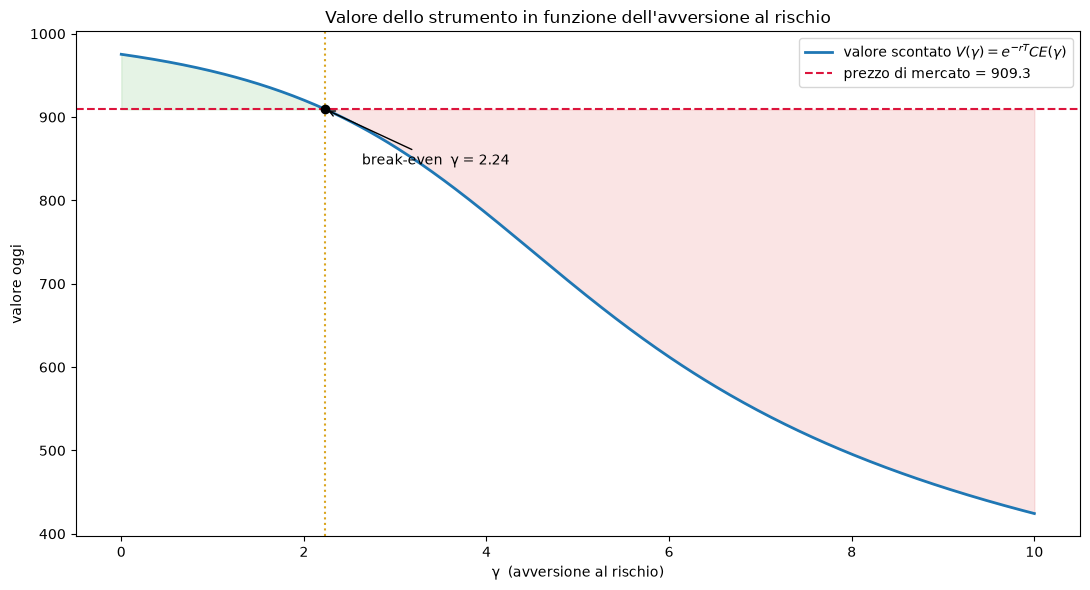

In [17]:
X = np.array(rendimenti, dtype=float)      # richiede conto_non_normalizzato = True
r = 0.03
T = giorni_durata / 365.24
disc = np.exp(-r*T)

def V(g):                                  # valore scontato al variare di gamma
    ce = np.exp(np.mean(np.log(X))) if abs(g-1) < 1e-9 else np.mean(X**(1-g))**(1/(1-g))
    return disc * ce

gammas = np.linspace(0, 10, 400)
vals = np.array([V(g) for g in gammas])

# gamma di break-even: dove la curva incrocia il prezzo
gamma_be = None
sign = np.sign(vals - prezzo)
idx = np.where(np.diff(sign) != 0)[0]
if len(idx):
    i = idx[0]; g0, g1 = gammas[i], gammas[i+1]; v0, v1 = vals[i], vals[i+1]
    gamma_be = g0 + (prezzo - v0) * (g1 - g0) / (v1 - v0)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(gammas, vals, lw=2, color="tab:blue", label=r"valore scontato $V(\gamma)=e^{-rT}CE(\gamma)$")
ax.axhline(prezzo, color="crimson", ls="--", lw=1.5, label=f"prezzo di mercato = {prezzo:.1f}")

# zone conviene (verde) / non conviene (rosso)
ax.fill_between(gammas, vals, prezzo, where=(vals >= prezzo), color="tab:green", alpha=0.12)
ax.fill_between(gammas, vals, prezzo, where=(vals <  prezzo), color="tab:red",   alpha=0.12)

if gamma_be is not None:
    ax.axvline(gamma_be, color="goldenrod", ls=":", lw=1.5)
    ax.plot(gamma_be, prezzo, "o", color="black", zorder=5)
    ax.annotate(f"break-even  γ = {gamma_be:.2f}",
                xy=(gamma_be, prezzo),
                xytext=(gamma_be + 0.4, prezzo - (vals.max()-vals.min())*0.12),
                arrowprops=dict(arrowstyle="->"))

ax.set_xlabel("γ  (avversione al rischio)")
ax.set_ylabel("valore oggi")
ax.set_title("Valore dello strumento in funzione dell'avversione al rischio")
ax.legend()
plt.tight_layout()
plt.show()